# Convolution Fundamentals — Notebook 1/4

## Lesson: Technical Aspects of CNNs in PyTorch

This notebook is a practical and theoretical guide to the **Fundamentals of Convolution** using the **PyTorch** library. It serves as the first part (1/4) of a study on Convolutional Neural Networks (CNNs), focusing on how filters operate and how hyperparameters shape image processing.

### Objective

Understand, in practice, **what happens** when we apply a convolution operation to an image. This notebook is the theoretical foundation: here we will manually manipulate tensors, change `kernel_size`, `padding`, `stride`, compare `MaxPool` with `AvgPool`, and apply `BatchNorm2d`.

### What we will cover

1. **Convolution Operation:** Load an image and inspect its shape `[C, H, W]`.
2. **Feature Maps:** Apply `nn.Conv2d` with random weights and visualize the resulting activation maps.
3. **Hyperparameters:** Compare kernels of sizes **3, 5, and 7** and demonstrate the effect of **padding** and **stride** on the output shape.
4. **Output Formulas:** Verify the formula $H_{out} = \frac{H_{in} + 2P - K}{S} + 1$.
5. **Pooling:** Compare **MaxPool2d** (detection preservation) and **AvgPool2d** (smoothing).
6. **Manual Filters (Sobel):** Implement a manual convolution with the **Sobel kernel** for edge detection.
7. **Normalization:** Apply **BatchNorm2d** and observe the statistical effect (mean/std) before and after.
8. **Fixation Exercises.**

### Prerequisites
- Basic knowledge of MLP in PyTorch.
- Array manipulation with Numpy.

## 1. Imports

We will use `torch`, `torch.nn` (layers), `torch.nn.functional` (functional versions of layers), `torchvision` (datasets/transforms), plus `PIL` and `matplotlib` for images.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Fixa seed: como vamos inicializar pesos aleatoriamente, queremos reprodutibilidade
torch.manual_seed(0)
np.random.seed(0)

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")

PyTorch: 2.12.0
Torchvision: 0.27.0


## 2. Loading ONE image

Let's take an image from **CIFAR-10** (32x32 RGB). É pequena, leve e suficiente para ilustrar a operação. O `download=True` baixa o dataset na primeira execução.

Importante: a imagem original do CIFAR é PIL; aplicamos `ToTensor()` para virar `Tensor` no formato `[C, H, W]` com valores em `[0, 1]`.

Shape do tensor: torch.Size([3, 32, 32])   # [C, H, W]
Dtype: torch.float32
Range de valores: [0.035, 0.973]
Classe: horse


/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


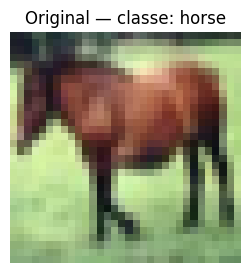

In [2]:
# Baixa um único batch do CIFAR-10 (só precisamos de UMA imagem para visualizar)
transform = T.Compose([T.ToTensor()])
cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Pega a primeira imagem do dataset
img_tensor, label = cifar[7]   # qualquer índice serve; escolhi 7
print(f"Shape do tensor: {img_tensor.shape}   # [C, H, W]")
print(f"Dtype: {img_tensor.dtype}")
print(f"Range de valores: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")
print(f"Classe: {cifar.classes[label]}")

# Para visualizar com matplotlib precisamos permutar para [H, W, C]
plt.figure(figsize=(3, 3))
plt.imshow(img_tensor.permute(1, 2, 0).numpy())
plt.title(f"Original — classe: {cifar.classes[label]}")
plt.axis('off')
plt.show()

## 3. Applying `nn.Conv2d`

The `nn.Conv2d` layer is the **central operation** of a CNN. Ela faz o produto de convolução entre o input e um banco de filtros aprendíveis. Parâmetros importantes:

- `in_channels`: canais de entrada (3 para RGB).
- `out_channels`: quantidade de **filtros** (cada filtro produz UM mapa de ativação na saída).
- `kernel_size`: tamanho da janela do filtro (3x3, 5x5, etc.).
- `padding`: zeros adicionados nas bordas; controla se a saída encolhe ou não.
- `stride`: passo do filtro; `stride=2` reduz a resolução pela metade.

Vamos criar uma `Conv2d` com 16 filtros 3x3 e ver o que sai. Os pesos começam **aleatórios**, então os feature maps refletirão filtros aleatórios — não detectores treinados. O ponto é entender as **dimensões**.

In [3]:
# Conv2d com 16 filtros 3x3 sobre uma imagem RGB
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

# Para passar pela rede precisamos do shape [N, C, H, W] (lote de imagens).
# Usamos unsqueeze(0) para adicionar a dimensão de batch
input_batch = img_tensor.unsqueeze(0)   # [1, 3, 32, 32]
print(f"Entrada: {input_batch.shape}")

# Inferência: rodamos a conv (sem treinar). torch.no_grad() poupa memória, já que não vamos backward.
with torch.no_grad():
    output = conv(input_batch)

print(f"Saída:   {output.shape}   # [N, out_channels, H, W]")
# Note: H e W permaneceram 32 graças ao padding=1 — vamos discutir isso adiante.

Entrada: torch.Size([1, 3, 32, 32])
Saída:   torch.Size([1, 16, 32, 32])   # [N, out_channels, H, W]


### Visualizing 8 of the 16 feature maps

Cada um dos 16 canais de saída é uma "resposta" diferente da imagem aos filtros. Como os pesos são aleatórios, esperamos padrões aleatórios — mas note como cada mapa **realça regiões diferentes** da imagem.

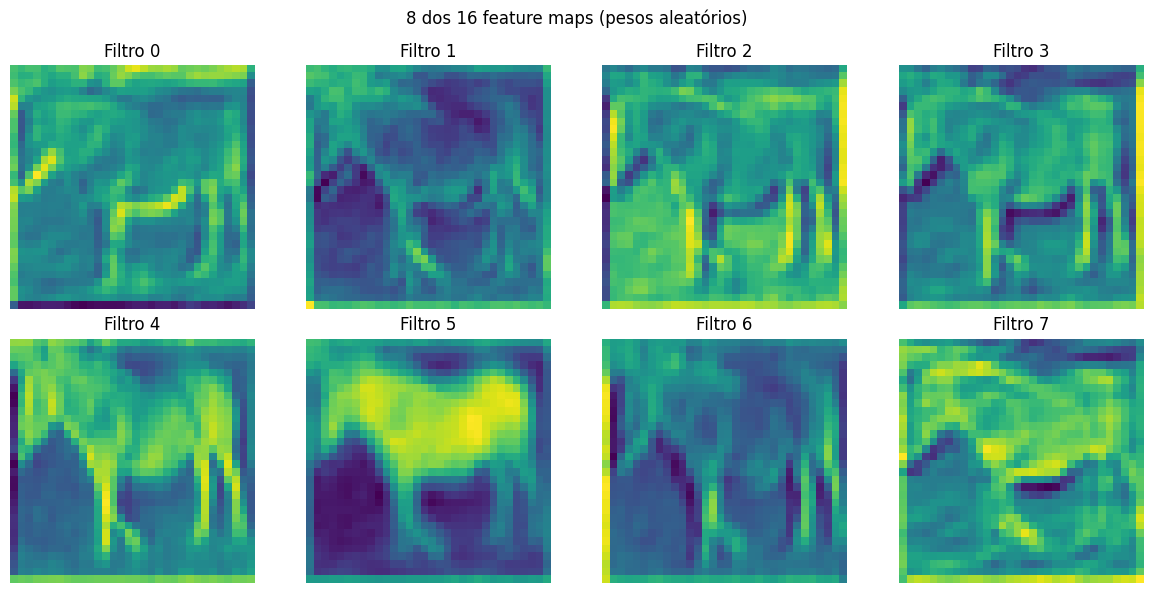

In [4]:
# Mostramos os primeiros 8 dos 16 feature maps
feature_maps = output[0]   # remove batch -> [16, 32, 32]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    fm = feature_maps[i].detach().numpy()
    ax.imshow(fm, cmap='viridis')
    ax.set_title(f"Filtro {i}")
    ax.axis('off')
plt.suptitle("8 dos 16 feature maps (pesos aleatórios)")
plt.tight_layout()
plt.show()

## 4. Changing `kernel_size`: 3, 5, and 7

O `kernel_size` define o **campo receptivo local** da convolução. Quanto maior o kernel, mais contexto cada saída "enxerga" — mas também mais parâmetros.

Observe como o shape da saída muda **se não usarmos padding**. Pela fórmula:

$$H_{out} = \frac{H_{in} + 2P - K}{S} + 1$$

Com `padding=0`, `stride=1`:
- `K=3` → saída = `32 - 3 + 1 = 30`
- `K=5` → saída = `32 - 5 + 1 = 28`
- `K=7` → saída = `32 - 7 + 1 = 26`

In [5]:
for k in [3, 5, 7]:
    # Sem padding, para mostrar como a saída encolhe
    conv_k = nn.Conv2d(3, 8, kernel_size=k, padding=0)
    with torch.no_grad():
        out_k = conv_k(input_batch)
    h_out = (32 + 2*0 - k) // 1 + 1
    n_params = sum(p.numel() for p in conv_k.parameters())
    print(f"kernel_size={k} | saída={tuple(out_k.shape)} | esperado H={h_out} | params={n_params}")

kernel_size=3 | saída=(1, 8, 30, 30) | esperado H=30 | params=224
kernel_size=5 | saída=(1, 8, 28, 28) | esperado H=28 | params=608
kernel_size=7 | saída=(1, 8, 26, 26) | esperado H=26 | params=1184


## 5. Padding: `'same'` versus no padding

`padding='same'` (string) **calcula automaticamente** o padding necessário para que `H_out == H_in` (quando `stride=1`). É o equivalente a `padding=(K-1)//2` para kernels ímpares.

Sem padding, a saída encolhe a cada conv. Com padding `'same'`, ela permanece, o que é prático para empilhar várias camadas sem encolher cedo demais.

In [6]:
# Conv sem padding
conv_nopad = nn.Conv2d(3, 8, kernel_size=3, padding=0)
# Conv com padding='same' (mantém H e W) — só funciona quando stride=1
conv_same  = nn.Conv2d(3, 8, kernel_size=3, padding='same')
# Conv com padding numérico equivalente
conv_pad1  = nn.Conv2d(3, 8, kernel_size=3, padding=1)

with torch.no_grad():
    o1 = conv_nopad(input_batch)
    o2 = conv_same(input_batch)
    o3 = conv_pad1(input_batch)

print(f"padding=0      -> {tuple(o1.shape)}")
print(f"padding='same' -> {tuple(o2.shape)}   # H, W preservados")
print(f"padding=1      -> {tuple(o3.shape)}   # equivalente para K=3")

padding=0      -> (1, 8, 30, 30)
padding='same' -> (1, 8, 32, 32)   # H, W preservados
padding=1      -> (1, 8, 32, 32)   # equivalente para K=3


## 6. Stride: convolution step

O `stride` controla quantos pixels o filtro avança a cada passo. `stride=2` é a forma "convolucional" de fazer downsampling — reduz pela metade a resolução **e** aprende a filtragem na hora.

Note que com `stride=2` e `padding=1`, a saída tem metade do tamanho.

In [7]:
for s in [1, 2, 4]:
    conv_s = nn.Conv2d(3, 8, kernel_size=3, stride=s, padding=1)
    with torch.no_grad():
        out_s = conv_s(input_batch)
    h_out_esperado = (32 + 2*1 - 3) // s + 1
    print(f"stride={s} | saída={tuple(out_s.shape)} | H esperado por fórmula={h_out_esperado}")

stride=1 | saída=(1, 8, 32, 32) | H esperado por fórmula=32
stride=2 | saída=(1, 8, 16, 16) | H esperado por fórmula=16
stride=4 | saída=(1, 8, 8, 8) | H esperado por fórmula=8


## 7. Pooling: `MaxPool2d` vs `AvgPool2d`

Pooling é uma operação **sem parâmetros** que reduz a resolução. Duas variantes:

- **MaxPool**: pega o **maior** valor da janela — preserva detecções mais fortes.
- **AvgPool**: pega a **média** — suaviza.

Pooling é tradicionalmente usado entre blocos conv para reduzir o mapa de ativação. Modernamente, muitas redes usam `stride=2` na convolução em vez disso.

Entrada:  (1, 3, 32, 32)
MaxPool:  (1, 3, 16, 16)
AvgPool:  (1, 3, 16, 16)


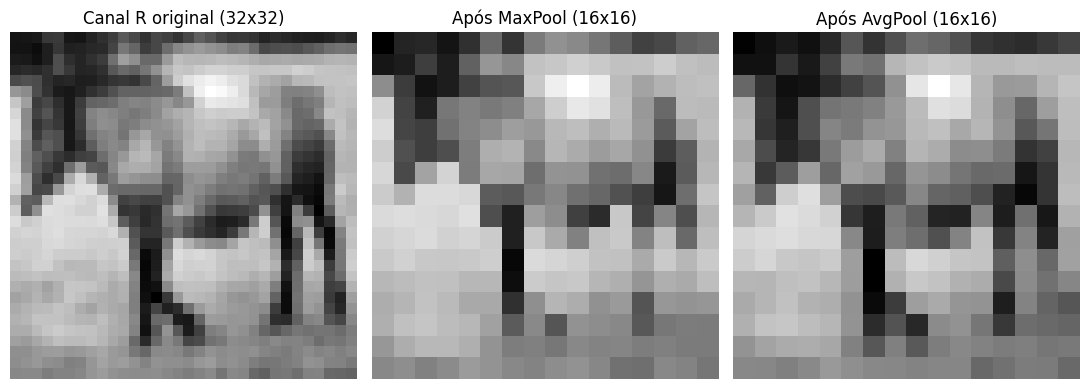

In [8]:
# Aplicamos pooling 2x2 com stride=2 (padrão)
maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

with torch.no_grad():
    out_max = maxpool(input_batch)
    out_avg = avgpool(input_batch)

print(f"Entrada:  {tuple(input_batch.shape)}")
print(f"MaxPool:  {tuple(out_max.shape)}")
print(f"AvgPool:  {tuple(out_avg.shape)}")

# Visualizamos o canal R original e depois dos dois poolings
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(input_batch[0, 0].numpy(), cmap='gray'); axes[0].set_title("Canal R original (32x32)")
axes[1].imshow(out_max[0, 0].numpy(),    cmap='gray'); axes[1].set_title("Após MaxPool (16x16)")
axes[2].imshow(out_avg[0, 0].numpy(),    cmap='gray'); axes[2].set_title("Após AvgPool (16x16)")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 8. Manual convolution with Sobel kernel

Até agora deixamos o PyTorch criar os pesos aleatoriamente. Agora vamos fazer o **contrário**: especificar manualmente um kernel famoso — o **operador de Sobel** — que detecta **bordas horizontais** ou **verticais**.

O Sobel-X clássico (detecta bordas verticais) é:

```
[ -1  0  1 ]
[ -2  0  2 ]
[ -1  0  1 ]
```

Para usar com `F.conv2d` precisamos do tensor no formato `[out_channels, in_channels, K, K]`. Vamos aplicar em **escala de cinza** para simplificar.

Imagem gray: torch.Size([1, 1, 32, 32])
Shape do kernel: torch.Size([2, 1, 3, 3])
Saída: torch.Size([1, 2, 32, 32])   # 2 canais: Sobel-X e Sobel-Y


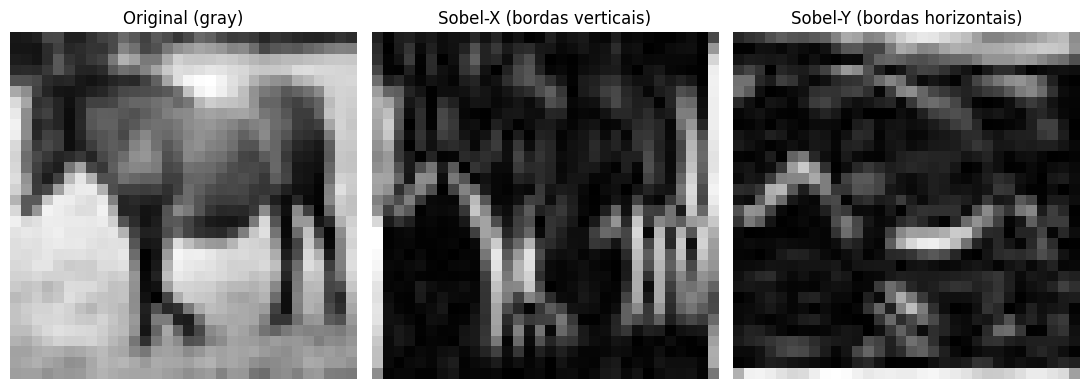

In [9]:
# Converte a imagem para escala de cinza usando a média dos canais
gray = img_tensor.mean(dim=0, keepdim=True)   # [1, H, W]
gray_batch = gray.unsqueeze(0)                # [1, 1, H, W]
print(f"Imagem gray: {gray_batch.shape}")

# Define manualmente os kernels Sobel
sobel_x = torch.tensor([[-1., 0., 1.],
                        [-2., 0., 2.],
                        [-1., 0., 1.]])

sobel_y = torch.tensor([[-1., -2., -1.],
                        [ 0.,  0.,  0.],
                        [ 1.,  2.,  1.]])

# Empacota num tensor [out_channels=2, in_channels=1, 3, 3]
kernel = torch.stack([sobel_x, sobel_y]).unsqueeze(1)
print(f"Shape do kernel: {kernel.shape}")

# F.conv2d aceita o tensor de pesos diretamente — útil quando NÃO queremos pesos aprendíveis
with torch.no_grad():
    edges = F.conv2d(gray_batch, kernel, padding=1)
print(f"Saída: {edges.shape}   # 2 canais: Sobel-X e Sobel-Y")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(gray_batch[0, 0].numpy(),       cmap='gray'); axes[0].set_title("Original (gray)")
axes[1].imshow(edges[0, 0].abs().numpy(),       cmap='gray'); axes[1].set_title("Sobel-X (bordas verticais)")
axes[2].imshow(edges[0, 1].abs().numpy(),       cmap='gray'); axes[2].set_title("Sobel-Y (bordas horizontais)")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 9. Verificando a fórmula do shape de saída

A fórmula geral é:

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

Vamos testar várias combinações de `K, P, S` e **comparar** o cálculo manual com o shape real que o PyTorch produz. Útil para depurar arquiteturas onde shapes não batem.

In [10]:
def shape_esperado(H_in, K, P, S):
    """Aplica a fórmula manualmente."""
    return (H_in + 2*P - K) // S + 1

# Lista de combinações para testar
casos = [
    # (K, P, S)
    (3, 0, 1),
    (3, 1, 1),
    (5, 2, 1),
    (3, 1, 2),
    (7, 3, 2),
    (1, 0, 1),
]

H_in = 32
print(f"{'K':>3} {'P':>3} {'S':>3} | {'fórmula':>8} | {'real':>8}")
print("-" * 38)
for K, P, S in casos:
    conv = nn.Conv2d(3, 4, kernel_size=K, padding=P, stride=S)
    with torch.no_grad():
        out = conv(input_batch)
    H_real = out.shape[-1]
    H_pred = shape_esperado(H_in, K, P, S)
    ok = "OK" if H_real == H_pred else "FALHOU"
    print(f"{K:>3} {P:>3} {S:>3} | {H_pred:>8} | {H_real:>8} {ok}")

  K   P   S |  fórmula |     real
--------------------------------------
  3   0   1 |       30 |       30 OK
  3   1   1 |       32 |       32 OK
  5   2   1 |       32 |       32 OK
  3   1   2 |       16 |       16 OK
  7   3   2 |       16 |       16 OK
  1   0   1 |       32 |       32 OK


## 10. `BatchNorm2d`: normalizando feature maps

`BatchNorm2d` normaliza cada canal de feature map dentro de um batch para ter **mean=0 e var=1** (depois aplica escala/shift aprendíveis). Os benefícios:

- Treina mais rápido.
- Permite usar **learning rates maiores**.
- Funciona como leve **regularização**.

Vamos comprovar mostrando o mean/std antes e depois.

In [11]:
# Geramos um tensor aleatório com escala arbitrária para ver a normalização agir
torch.manual_seed(42)
x = torch.randn(8, 16, 32, 32) * 5 + 10   # mean ~ 10, std ~ 5
print(f"ANTES da BN:")
print(f"  Mean por canal (8 primeiros): {x.mean(dim=[0,2,3])[:8].tolist()}")
print(f"  Std  por canal (8 primeiros): {x.std (dim=[0,2,3])[:8].tolist()}")

bn = nn.BatchNorm2d(num_features=16)
# Em modo .train(), BN calcula mean/std do batch. Em .eval(), usa running stats.
bn.train()
y = bn(x)

print(f"\nDEPOIS da BN:")
print(f"  Mean por canal (8 primeiros): {y.mean(dim=[0,2,3])[:8].tolist()}")
print(f"  Std  por canal (8 primeiros): {y.std (dim=[0,2,3])[:8].tolist()}")
# Note: mean ~ 0 e std ~ 1 (com leve variação por causa do bias/scale aprendíveis)

ANTES da BN:
  Mean por canal (8 primeiros): [9.990680694580078, 9.912814140319824, 10.072031021118164, 10.0615816116333, 9.932822227478027, 10.003334045410156, 9.989921569824219, 10.00851821899414]
  Std  por canal (8 primeiros): [5.054337024688721, 5.019243240356445, 5.016149997711182, 5.000767230987549, 5.005675315856934, 5.037661552429199, 4.943397045135498, 5.014055252075195]

DEPOIS da BN:
  Mean por canal (8 primeiros): [-7.147900760173798e-08, -1.0407529771327972e-07, 1.4505349099636078e-07, -8.102506399154663e-08, 2.4971086531877518e-08, -1.1757947504520416e-07, 5.0640664994716644e-09, 2.537854015827179e-08]
  Std  por canal (8 primeiros): [1.0000609159469604, 1.0000609159469604, 1.000060796737671, 1.000060796737671, 1.000060796737671, 1.000060796737671, 1.000060796737671, 1.000060796737671]


## 11. Juntando tudo: um mini bloco `Conv-BN-ReLU-Pool`

Esta é a célula básica de uma CNN moderna. Vamos rodar nossa imagem por um bloco simples e ver os shapes a cada etapa — para fixar a "vida" de um tensor dentro da rede.

In [12]:
bloco = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),   # mantém H, W
    nn.BatchNorm2d(32),                            # normaliza por canal
    nn.ReLU(inplace=True),                         # não-linearidade
    nn.MaxPool2d(2, 2)                             # reduz H, W pela metade
)

# Rodando o bloco
with torch.no_grad():
    saida = bloco(input_batch)

print(f"Entrada do bloco: {tuple(input_batch.shape)}")
print(f"Saída do bloco:   {tuple(saida.shape)}")

# Examinando cada etapa explicitamente
x = input_batch
print(f"\nEvolução do tensor:")
print(f"  Início         : {tuple(x.shape)}")
x = bloco[0](x); print(f"  Após Conv      : {tuple(x.shape)}")
x = bloco[1](x); print(f"  Após BN        : {tuple(x.shape)}")
x = bloco[2](x); print(f"  Após ReLU      : {tuple(x.shape)}")
x = bloco[3](x); print(f"  Após MaxPool   : {tuple(x.shape)}")

Entrada do bloco: (1, 3, 32, 32)
Saída do bloco:   (1, 32, 16, 16)

Evolução do tensor:
  Início         : (1, 3, 32, 32)
  Após Conv      : (1, 32, 32, 32)
  Após BN        : (1, 32, 32, 32)
  Após ReLU      : (1, 32, 32, 32)
  Após MaxPool   : (1, 32, 16, 16)


## 12. Exercises

Solve the three exercises below. Cada um vale como prática para fixar a fórmula e a intuição.

### Exercise 1 — Calculate shape manually

Considere um input `[1, 3, 224, 224]` (uma imagem RGB de 224x224, típica de ImageNet).

Aplique mentalmente as camadas abaixo e escreva o shape após cada uma. **Em seguida**, rode o código para verificar.

```
Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
MaxPool2d(kernel_size=3, stride=2, padding=1)
Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
Conv2d(128, 128, kernel_size=3, stride=2, padding=1)
```

In [13]:
# Exercício 1: Resolvido
# Shapes esperados (preenchidos):
#   Após Conv1   : [1, 64, 112, 112]
#   Após MaxPool : [1, 64, 56, 56]
#   Após Conv2   : [1, 128, 56, 56]
#   Após Conv3   : [1, 128, 28, 28]

teste = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
)

dummy = torch.randn(1, 3, 224, 224)
x = dummy
for camada in teste:
    x = camada(x)
    print(f"{camada.__class__.__name__:>12} -> {tuple(x.shape)}")

      Conv2d -> (1, 64, 112, 112)
   MaxPool2d -> (1, 64, 56, 56)
      Conv2d -> (1, 128, 56, 56)
      Conv2d -> (1, 128, 28, 28)


### Exercise 2 — Edge detector filter

Crie um kernel **3x3** que detecte **bordas diagonais** (do canto superior-esquerdo ao canto inferior-direito). Dica: combine elementos positivos numa diagonal e negativos na outra.

Aplique-o à imagem em escala de cinza e visualize. Compare com o resultado do Sobel-X.

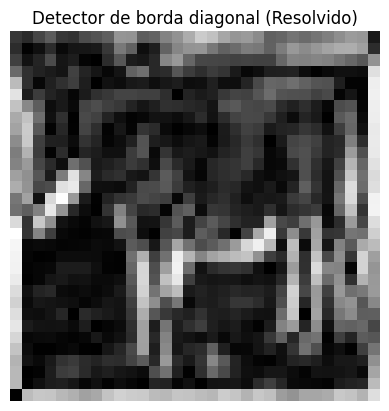

In [14]:
# Exercício 2: Resolvido
# Kernel 3x3 para detectar bordas diagonais (NW to SE)
kernel_diagonal = torch.tensor([
    [-2., -1.,  0.],
    [-1.,  0.,  1.],
    [ 0.,  1.,  2.],
])

# Coloca no shape [1, 1, 3, 3] para F.conv2d
k = kernel_diagonal.unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    saida = F.conv2d(gray_batch, k, padding=1)

plt.imshow(saida[0, 0].abs().numpy(), cmap='gray')
plt.title("Detector de borda diagonal (Resolvido)")
plt.axis('off')
plt.show()

### Exercise 3 — Counting parameters

Considere uma `Conv2d(in_channels=64, out_channels=128, kernel_size=3)` com bias.

1. **Calcule no papel** quantos parâmetros aprendíveis ela tem.
2. Use `.numel()` para verificar.

Lembre que cada filtro tem `in_channels * K * K` pesos + 1 bias.

In [15]:
# Exercício 3: Resolvido
# Cálculo:
# Pesos: out_channels * in_channels * K * K = 128 * 64 * 3 * 3 = 73728
# Bias : out_channels = 128
# Total: 73728 + 128 = 73856
# Sua resposta: 73856

conv_teste = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, bias=True)

total = sum(p.numel() for p in conv_teste.parameters())
peso  = conv_teste.weight.numel()
bias  = conv_teste.bias.numel()
print(f"Pesos: {peso}  (= 128 filtros * 64 canais * 3 * 3 = {128*64*3*3})")
print(f"Bias : {bias}   (= 128 — um por filtro)")
print(f"Total: {total}")

Pesos: 73728  (= 128 filtros * 64 canais * 3 * 3 = 73728)
Bias : 128   (= 128 — um por filtro)
Total: 73856


## Summary and next steps

Neste notebook você:

- Aplicou `nn.Conv2d` em uma imagem real e visualizou os feature maps.
- Comparou kernels 3, 5 e 7 e viu como afetam o shape.
- Demonstrou o efeito de `padding` e `stride`.
- Comparou `MaxPool2d` com `AvgPool2d`.
- Especificou um **kernel manual** (Sobel) com `F.conv2d`.
- Verificou a fórmula `H_out = (H_in + 2P - K) / S + 1`.
- Viu `BatchNorm2d` em ação.

### Próximo notebook

`02_cnn_cifar10_completa.ipynb` — Treinamos uma CNN **do zero** no CIFAR-10 com todas as boas práticas: data augmentation, BatchNorm, scheduler, checkpoint, TensorBoard, matriz de confusão.